In [130]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [131]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy import linalg as la

from jax.numpy import einsum

# for coloring lines
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import blochK
import blochK.observable as observable
from blochK.plotting import plot_FS, plot_bandstruc
from blochK.plotting.utils import extent
from blochK.plotting.publication import (
    paper_style,
    paper_style_small,
    revtex_textwidth,
    revtex_columnwidth,
    set_size,
)
from blochK.observable import conductivity_orbital_resolved

import plot_funcs as pf

import sys, os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from alter_surf.utils3D import projector2layer

import pickle

matplotlib.rcParams.update(
    {
        "font.size": 8,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [132]:
from matplotlib.colors import LinearSegmentedColormap

# colormaps

bwr_map = matplotlib.colormaps["bwr"]

cmap_bwr = matplotlib.colormaps["bwr"]
colors = [cmap_bwr(0.0), (0, 0, 0, 1), cmap_bwr(1.0)]
cmap_bkr = LinearSegmentedColormap.from_list("bkr", colors, N=256)


# spectral function calculation


# nx, ny = 300, 300
# img = np.zeros((ny, nx, 4))


# X, Y = np.meshgrid(np.linspace(0, 1, nx), np.linspace(0, 1, ny))
# img = two_param_color(X, Y, 1)


# plt.imshow(img, origin="lower", aspect="auto")
# plt.xlabel("x: blue → black → red")
# plt.ylabel("y: base → white")
# plt.show()

### define the model


In [133]:
from alter_surf.hamiltonian_CuMnAs import H_3D_fct, H_slab_fct
from alter_surf.hamiltonian_DLKK import (
    create_H_DLKK_3D,
    create_H_DLKK_3D_MF,
    create_H_DLKK_true3D,
)


################################
############# DLKK #############
################################

# Hparam = dict(len_z=30, delta=1, tp=0.3, tz=1, PBC=False, mAF=3, mu=3.1)
# # create Hamiltonian with MF parameters
# Hamil_2D = create_H_DLKK_3D(param=Hparam)
# Hparam_3d = dict(delta=1, tp=0.3, tz=1, PBC=True, mAF=3, mu=3.1)
# Hamil_3D = create_H_DLKK_true3D(param=Hparam_3d)
# model_name = "DLKK"


####################################
############# drumhead #############
####################################

# model_name = "Drumhead"
# Hparam = dict(len_z=21, t = 0.4, tz = 1.0, Delta0=0.6, Delta1=0.6,Delta3=0.6, mu=0.1)
# Hamil_2D = pf.slab_ham(Hparam)


# Hparam_3d = dict(t = 0.4, tz = 1.0, Delta0=0.6, Delta1=0.6,Delta3=0.6, mu=0.1)
# H3D = blochK.Hamiltonian3D(H_3D_fct, param= Hparam_3d, basis = ['spin','z-layer','sublattice'])
# H3D.add_operator('spin',np.array([1,1,1,1,-1,-1,-1,-1]))


################################
############# Weyl #############

model_name = "Weyl"
Hparam = dict(
    len_z=21, t=0.4, tz=1.0, Delta0=0.6, Delta1=0.6, Delta3=0.6, mu=0.1, dtpp=0.2
)
Hamil_2D = pf.slab_ham(Hparam)

Hparam_3d = dict(t=0.4, tz=1.0, Delta0=0.6, Delta1=0.6, Delta3=0.6, mu=0.1, dtpp=0.2)
Hamil_3D = blochK.Hamiltonian3D(
    H_3D_fct, param=Hparam_3d, basis=["spin", "z-layer", "sublattice"]
)
Hamil_3D.add_operator("spin", np.array([1, 1, 1, 1, -1, -1, -1, -1]))

(84, 88) 84


### 2D spectral function 

In [134]:
# make a path from Γ to X to M to Y to Γ
n_k_2d_path = 200
path_2d = np.array([[1, 1], [0, 1], [0, 0], [1, 0], [1, 1], [0, 0]])
k_walk_2d = (
    np.concatenate(
        [
            np.linspace(path_2d[i], path_2d[i + 1], n_k_2d_path, endpoint=False)
            for i in range(len(path_2d) - 1)
        ]
    )
    * np.pi
)
k_labels_2d = [r"$M$", r"$Y$", r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]
label_positions_2d = np.linspace(0, len(k_walk_2d), len(k_labels_2d)).astype(int)

# diagonalise along the k_walk
es_2d, psis_2d = Hamil_2D.diagonalize(*k_walk_2d.T)

In [ ]:
spillover = 0.25
n_k_grid = 101

k_values_slice = np.linspace(
    -np.pi * (1 + spillover), np.pi * (1 + spillover), n_k_grid, endpoint=False
)

KX, KY = np.meshgrid(k_values_slice, k_values_slice)

es_slice, psis_slice = Hamil_2D.diagonalize(KX, KY)

In [ ]:
e_vals = np.linspace(np.min(es_2d), np.max(es_2d), 100)
eta = 5e-2
n_layers = Hparam["len_z"]


specs_boundary_walk = pf.make_spectral_functions(
    Hamil_2D, [0], psis_2d, es_2d, e_vals, eta
)
specs_bulk_walk = pf.make_spectral_functions(
    Hamil_2D, [-1], psis_2d, es_2d, e_vals, eta
)

colors_bulk_walk, colors_boundary_walk = pf.normalize_and_find_colours(
    specs_bulk_walk, specs_boundary_walk
)

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1.]


Make the plots for the horizontal slices


In [ ]:
# make the spectral function
from figures_for_the_paper.plot_funcs import spec_func


fermi_level = np.array([0])
eta = 5e-2


specs_boundary_slice = pf.make_spectral_functions(
    Hamil_2D, [0], psis_slice, es_slice, fermi_level, eta
)
specs_bulk_slice = pf.make_spectral_functions(
    Hamil_2D, [-1], psis_slice, es_slice, fermi_level, eta
)

colors_bulk_slice, colors_boundary_slice = pf.normalize_and_find_colours(
    specs_bulk_slice, specs_boundary_slice
)

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1.]


plot it all

[Text(-3.141592653589793, 0, '$-\\pi$'), Text(3.141592653589793, 0, '$\\pi$')]

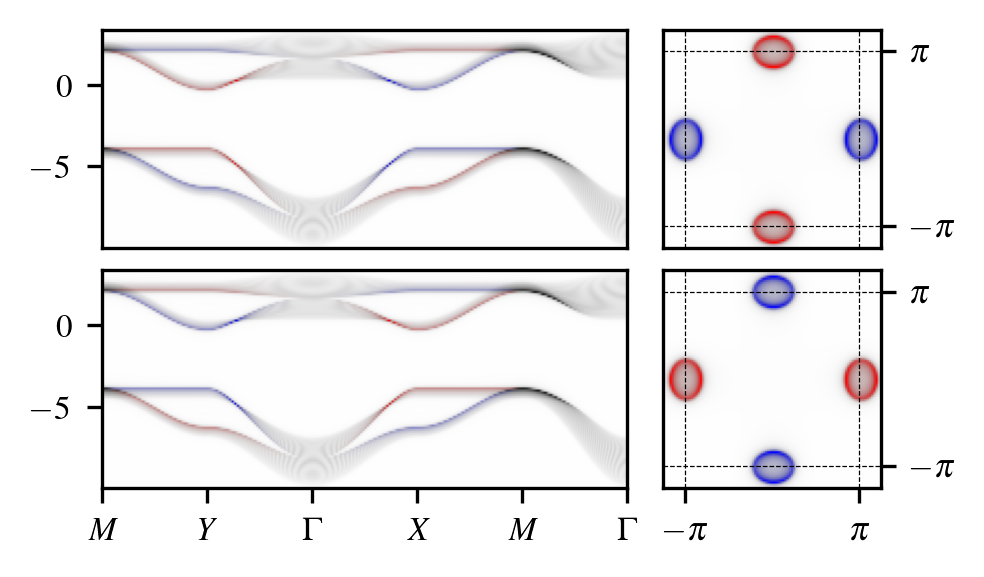

In [ ]:
from matplotlib.gridspec import GridSpec

w = 2.3
h = 1.0
wspace = 0.08

fig = plt.figure(
    figsize=(aps_halfwidth, aps_halfwidth * ((h + 1) / (w + 1 + wspace + 0.02))),
    dpi=300,
)
gs = GridSpec(
    2, 2, width_ratios=[w, h], height_ratios=[1, 1], wspace=wspace, hspace=0.1
)

# Left column (share x and y)
ax_l1 = fig.add_subplot(gs[0, 0])
ax_l2 = fig.add_subplot(gs[1, 0], sharex=ax_l1, sharey=ax_l1)

# Right column (share x and y)
ax_r1 = fig.add_subplot(gs[0, 1])
ax_r2 = fig.add_subplot(gs[1, 1], sharex=ax_r1, sharey=ax_r1)


ax_l1.imshow(
    colors_boundary_walk,
    extent=(0, len(k_walk_2d), e_vals[0], e_vals[-1]),
    aspect="auto",
    origin="lower",
)

ax_l2.imshow(
    colors_bulk_walk,
    extent=(0, len(k_walk_2d), e_vals[0], e_vals[-1]),
    aspect="auto",
    origin="lower",
)


ax_r1.imshow(
    np.swapaxes(colors_boundary_slice, 0, 1),
    extent=(
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
    ),
)

ax_r2.imshow(
    np.swapaxes(colors_bulk_slice, 0, 1),
    extent=(
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
    ),
)


for a in (ax_r1, ax_r2):
    a.axhline(-np.pi, color="k", ls="--", lw=0.3)
    a.axhline(np.pi, color="k", ls="--", lw=0.3)
    a.axvline(-np.pi, color="k", ls="--", lw=0.3)
    a.axvline(np.pi, color="k", ls="--", lw=0.3)

ax_l1.tick_params(
    axis="both",
    which="both",
    bottom=False,
    left=True,
    right=False,
    labelbottom=False,
    labelleft=True,
)
ax_r1.tick_params(
    axis="both",
    which="both",
    bottom=False,
    top=False,
    left=False,
    right=True,
    labelbottom=False,
    labelright=True,
    labelleft=False,
)
ax_r2.tick_params(
    axis="both",
    which="both",
    bottom=True,
    top=False,
    left=False,
    right=True,
    labelbottom=True,
    labelright=True,
    labelleft=False,
)

# fig.subplots_adjust(left=0.08, right=0.92)

ax_l2.set_xticks(label_positions_2d, k_labels_2d)
# ax_l1.axhline(0, color="k", ls="--", lw=0.3)
# ax_l2.axhline(0, color="k", ls="--", lw=0.3)

ax_r2.set_xticks([-np.pi, np.pi])
ax_r2.set_yticks([-np.pi, np.pi])
ax_r2.set_yticklabels(["$-\\pi$", "$\\pi$"])
ax_r2.set_xticklabels(["$-\\pi$", "$\\pi$"])

# ax_l1.set_ylabel("$E/t$")
# ax_l2.set_ylabel("$E/t$")

# plt.savefig(f"{model_name}_spec.png", bbox_inches="tight", transparent=True, dpi=350)

In [ ]:
# spin splitter

cond_tensor = conductivity_orbital_resolved(
    Hamil_2D, Lk=40, optimize="path"
)  # .shape=(localH,x,y)

sum_layers = 2  # sum always n_layers layers up
len_z = Hparam["len_z"]


cond_tensor2 = np.reshape(
    cond_tensor, (len_z, 2, 2, 2, 2)
)  # .shape=(layer,spin,sublattice,x,y)


# cond_tensor2 = cond_tensor2.reshape(
#     -1, sum_layers, 2, 2, 2, 2
# )  # .shape=(layer/sum_layers,sum_layers,sublattice,spin,x,y)

# cond_xx = np.sum(
#     cond_tensor2[:, :, :, :, 0, 0], axis=(1, 3)
# )  # .shape=(layer/sum_layers,spin)
# spin_cond_xx = cond_xx[:, 0] - cond_xx[:, 1]  # difference of spin indices
# cond0_xx = cond_xx[:, 0] + cond_xx[:, 1]  # total cond: sum of spin indices
# # indices is fixed by sum_layers
# layers = np.arange(0, len_z + 1 - sum_layers, sum_layers)

# spin_splitter = 2 * np.arctan(spin_cond_xx / cond0_xx) * 180 / np.pi

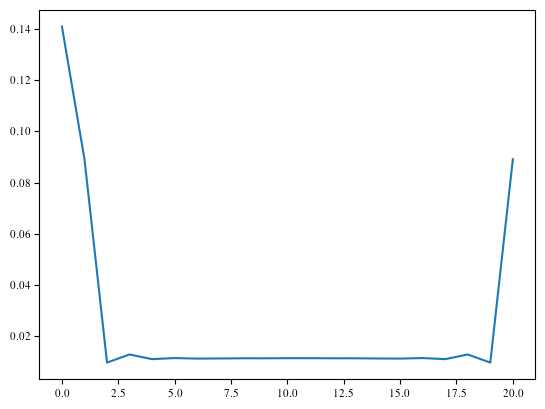

In [ ]:
plt.plot(cond_tensor2[:, 0, 0, 0, 0])
plt.show()

In [ ]:
path_3d = np.array(
    [
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 0],
        [0, 1, 0],
        [1, 1, 0],
        [1, 1, 1],
        [0, 1, 0],
        [0, 0, 1],
    ]
)

k_walk_3d = (
    np.concatenate(
        [
            np.linspace(path_3d[i], path_3d[i + 1], n_k_2d_path, endpoint=False)
            for i in range(len(path_3d) - 1)
        ]
    )
    * np.pi
)

labels_3d = [r"Y", r"X", r"$\Gamma$", r"Y", r"M", r"R", r"Y", r"Z"]
label_positions_3d = np.linspace(0, len(k_walk_3d), len(labels_3d)).astype(int)

es_2d, vs = Hamil_3D.diagonalize(*k_walk_3d.T)

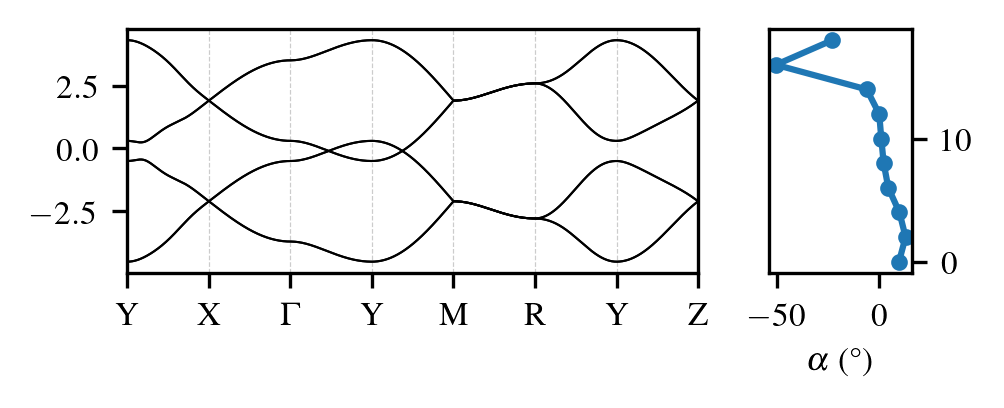

In [ ]:
w = 2
wspace = 0.2
fig = plt.figure(
    figsize=(aps_halfwidth, aps_halfwidth * ((h + 1) / (w + 1 + wspace)) / 2), dpi=300
)
gs = GridSpec(1, 2, width_ratios=[4, 1], wspace=wspace, hspace=0.05)

# Left column (share x and y)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])


ax1.plot(es_2d.T, color="k", lw=0.5)


ax2.tick_params(
    axis="both",
    which="both",
    bottom=True,
    top=False,
    left=False,
    right=True,
    labelbottom=True,
    labelright=True,
    labelleft=False,
)
ax2.plot(spin_splitter, layers, "o-", markersize=3)
# ax1.set_ylabel("$E/t$")
# ax2.set_ylabel("Layer")
ax2.set_xlabel("$\\alpha$ (°)")
ax2.yaxis.set_label_position("right")

# momenta

for v in label_positions_3d:
    ax1.axvline(v, color="k", ls="--", lw=0.3, alpha=0.2)

ax1.set_xlim(0, len(k_walk_3d))
ax1.set_xticks(label_positions_3d, labels_3d)
# ax1.set_xticks(label_positions, k_labels)
plt.savefig(
    f"{model_name}_band_spin.png", bbox_inches="tight", transparent=True, dpi=350
)
plt.show()